# Software Fault-Injections Results for TNS 2025

To generate the different plots and results, run the following jupyter notebook.

## Initial part (imports, paths, etc)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from itertools import product
import re

DATAPATH = "fi_results"
SORTED_INDICES_PATH = "data/sorted_indices"

SAVE_PATH = "parsed_results"

In [2]:
def parse_filename(filename):
    """
    Parse CSV filenames to extract components.
    
    Args:
        filename (str): CSV filename with format 
                        "<model>_<dataset>_<precision>_<microop>_<float_threshold>_<seed>_layer-<layer>.csv"
    
    Returns:
        dict: Dictionary containing the extracted components
    """
    # Remove the .csv extension
    filename = filename.replace('.csv', '')
    
    # Split the filename by underscores
    parts = filename.split('_')
    
    # Extract the layer from the last part (format: layer-LAYER)
    layer_part = parts[-1]
    layer = layer_part.split('-')[1]
    
    # Extract the seed from the second to last part
    seed = int(parts[-2])
    
    # Extract the learning rate (we're not returning this as per requirements)
    # float_threshold = parts[-3]
    
    # Extract the microop
    microop = parts[-4]
    
    # Extract the precision
    precision = parts[-5]
    
    # Extract the dataset
    dataset = parts[-6]
    
    # Extract the model (everything before the dataset)
    # The model name might contain underscores, so we need to rebuild it
    model_parts = parts[:-6]
    model = "_".join(model_parts)
    
    return {
        "model": model,
        "dataset": dataset,
        "precision": precision,
        "microop": microop,
        "seed": seed,
        "layer": layer
    }


def parse_filename2(filename):
    """
    Parse CSV filenames to extract components using regular expressions.
    
    Args:
        filename (str): CSV filename with format 
                        "<model>_<dataset>_<precision>_<microop>_<float_threshold>_<seed>_layer-<layer>_it-<injection_type>.csv"
    
    Returns:
        dict: Dictionary containing the extracted components
    """
    # Remove extension
    filename = filename.replace('.csv', '')

    # Regex pattern
    pattern = re.compile(
        r'^(?P<model>.+?)_'                              # model (non-greedy)
        r'(?P<dataset>[^_]+)_'                           # dataset
        r'(?P<precision>[^_]+)_'                         # precision
        r'(?P<microop>[^_]+)_'                           # microop
        r'(?P<float_threshold>[\d.eE+-]+)_'              # float_threshold (scientific notation supported)
        r'(?P<seed>\d+)_'
        r'layer-(?P<layer>.+?)_'                         # layer (non-greedy)
        r'it-(?P<injection_type>.+)$'                    # injection_type
    )

    match = pattern.match(filename)
    if not match:
        raise ValueError(f"Filename format is incorrect: {filename}")

    # Extract fields
    info = match.groupdict()
    
    # Convert seed to int
    info['seed'] = int(info['seed'])

    # Return selected fields only (not float_threshold)
    return {
        "model": info["model"],
        "dataset": info["dataset"],
        "precision": info["precision"],
        "microop": info["microop"],
        "seed": info["seed"],
        "layer": info["layer"],
        "injection_type": info["injection_type"]
    }



def parse_filename3(filename):
    """
    Parse CSV filenames to extract components.
    
    Args:
        filename (str): CSV filename with format 
                        "<model>_<dataset>_<precision>_<microop>_<float_threshold>_<seed>_layer-<layer>_it-<injection_type>_seed-specif-<specific_seed>.csv"
    
    Returns:
        dict: Dictionary containing the extracted components
    """
    # Remove the .csv extension
    filename = filename.replace('.csv', '')

    # Split the filename by underscores
    parts = filename.split('_')[:]

    # Extract specific_seed from the last part (format: seed-specif-<specific_seed>)
    specific_seed = int(parts[-1].split('-')[2])

    # Extract injection_type from the second to last part (format: it-<injection_type>)
    injection_type = parts[-2].split('-')[1]

    # Extract the layer from the third to last part (format: layer-<layer>)
    layer = parts[-3].split('-')[1]

    # Extract the seed from the fourth to last part
    seed = int(parts[-4])

    # Extract the microop
    microop = parts[-6]

    # Extract the precision
    precision = parts[-7]

    # Extract the dataset
    dataset = parts[-8]

    # Extract the model (everything before the dataset)
    model_parts = parts[:-8]
    model = "_".join(model_parts)

    return {
        "model": model,
        "dataset": dataset,
        "precision": precision,
        "microop": microop,
        "seed": seed,
        "layer": layer,
        "injection_type": injection_type,
        "specific_seed": specific_seed
    }

In [3]:
def get_result_files(file_path):
    """
    Get the list of result files in the given path.
    
    Args:
        file_path (str): Path to the directory containing the result files
    
    Returns:
        list: List of CSV files in the directory
    """
    # Get the list of files in the directory
    files = os.listdir(file_path)
    
    # Filter out only the CSV files
    result_files = [f for f in files if f.endswith('.csv')]
    
    return result_files

In [4]:
def get_result_for_config(path, file):
    """
    Get the results for a given configuration.
    
    Args:
        file (str): Path to the CSV file containing the results
    
    Returns:
        pd.DataFrame: DataFrame containing the results
    """
    # Read the CSV file
    df = pd.read_csv(os.path.join(path, file))
    total = len(df)
    
    df = df[df["prediction_without_fault"] != df["prediction_with_fault"]]
    critical = len(df)

    return df, critical, total

def get_result_for_config2(file):
    """
    Get the results for a given configuration.
    
    Args:
        file (str): Path to the CSV file containing the results
    
    Returns:
        pd.DataFrame: DataFrame containing the results
    """
    # Read the CSV file
    df = pd.read_csv(file)
    total = len(df)
    
    df = df[df["prediction_without_fault"] != df["prediction_with_fault"]]
    critical = len(df)

    return df, critical, total

In [5]:
def get_criticality(file, threshold=1e-5):
    """
    Get the criticality for a given configuration.
    
    Args:
        file (str): Path to the CSV file containing the results
    
    Returns:
        pd.DataFrame: DataFrame containing the criticality
    """
    # Read the CSV file
    df = pd.read_csv(file)
    
    total = len(df)
    
    df_crit = df[df["prediction_without_fault"] != df["prediction_with_fault"]]
    critical = len(df_crit)

    # Calculate the criticality
    df["Crit SDC"] = df["prediction_without_fault"] != df["prediction_with_fault"]
    df["SDC"] = ((df["top1_wo_fault"] - df["top1_w_fault"]) > threshold) | (df["prediction_without_fault"] != df["prediction_with_fault"])

    sdc = df[df["SDC"] == True]
    sdc = len(sdc)
    
    return df, sdc, critical, total

In [6]:
def get_binned_data(df, n_bins=100):
    """
    Return the binned data using numpy histogram approach
    """
    # Compute histogram for confidence (your original way)
    counts, bins = np.histogram(df['confidence'],
                                bins=n_bins, 
                                # range=(0.0, 1.0)
                                )
    # Compute bin midpoints (your original way)
    # bin_midpoints = 0.5 * (bins[:-1] + bins[1:])
    bin_midpoints = np.arange(0.0, 1.0, 0.01)
    
    # Get bin indices for Critical SDC summing
    bin_indices = np.digitize(df['confidence'], bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    # Sum Critical SDC for each bin and count samples per bin
    sdc_sum = np.zeros(n_bins)
    critical_sdc_sum = np.zeros(n_bins)
    bin_sample_count = np.zeros(n_bins)
    for i in range(len(df)):
        bin_idx = bin_indices[i]
        sdc_sum[bin_idx] += df['SDC'].iloc[i]
        critical_sdc_sum[bin_idx] += df['Crit SDC'].iloc[i]
        bin_sample_count[bin_idx] += 1
    
    # Calculate average Critical SDC per bin (avoid division by zero)
    critical_sdc_avg = np.divide(critical_sdc_sum, bin_sample_count, 
                                out=np.zeros_like(critical_sdc_sum), 
                                where=bin_sample_count!=0)
    
    sdc_avg = np.divide(sdc_sum, bin_sample_count,
                        out=np.zeros_like(sdc_sum), 
                        where=bin_sample_count!=0)
    
    return pd.DataFrame({
        'bin_midpoints': bin_midpoints,
        'counts': counts,  # This is your frequency
        'SDC PVF%': sdc_avg,
        'Crit SDC PVF%': critical_sdc_avg,
        # 'bins': bins
    })

In [7]:
def get_vit_confidence_set_criticality(dirs, subset, model, threshold=1e-5):
    res = []
    for dir in dirs:
        files = os.listdir(dir)
        files = [f for f in files if f.endswith('.csv') and model in f]
        for file in files:
            df = pd.read_csv(os.path.join(dir, file))
            df["confidence"] = df["top1_wo_fault"] - df["top2_wo_fault"]
            if subset == "low":
                df_filtered = df.sort_values(by=["confidence"], ascending=True)
                df_filtered = df_filtered[11:43]
            elif subset == "high":
                df_filtered = df.sort_values(by=["confidence"], ascending=False)
                df_filtered = df_filtered[31:63]
            
            res.append(df_filtered)
            
    df = pd.concat(res, ignore_index=True)
    df["subset"] = subset
    df["model"] = model
    df["Crit SDC"] = df["prediction_without_fault"] != df["prediction_with_fault"]
    df["SDC"] = ((df["top1_w_fault"].isna()) | (df["top1_wo_fault"] - df["top1_w_fault"]) > threshold) | (df["prediction_without_fault"] != df["prediction_with_fault"])
    df = df.groupby(["model", "subset", "confidence"]).agg({
        "SDC": 'sum',
        "Crit SDC": 'sum',
    }).reset_index()
    return df


In [8]:
def get_concat_df_confidence(model, layer, paths_list):
    sorted_confidence_dfs = []
    threshold = 1e-5
    for folder in paths_list:
        for file in os.listdir(folder):
            if not file.endswith('.csv'):
                continue
            if model not in file or f"layer-{layer}_it-" not in file:
                continue
            # get seed from filename
            
            df = pd.read_csv(os.path.join(folder, file))
            df["confidence"] = df["top1_wo_fault"] - df["top2_wo_fault"]
            df["SDC"] = ((df["top1_wo_fault"] - df["top1_w_fault"]) > threshold) | (df["prediction_without_fault"] != df["prediction_with_fault"])
            df["Crit SDC"] = df["prediction_without_fault"] != df["prediction_with_fault"]
            df = df.sort_values(by=["confidence"], ascending=True).reset_index(drop=True)
            df["index"] = df.index
            df["index"] = df["index"].astype(int)
            if "swin" in file:
                df["model"] = "swin"
            elif "vit" in file:
                df["model"] = "vit"
            sorted_confidence_dfs.append(df)

    sorted_confidence_df = pd.concat(sorted_confidence_dfs, ignore_index=True)
    del sorted_confidence_dfs
    sorted_confidence_df = sorted_confidence_df.sort_values(by=["confidence"], ascending=True)
    sorted_confidence_df = sorted_confidence_df.groupby(["model", "index", "ground_truth", "prediction_without_fault"]).agg({
        'confidence': 'min',
        'SDC': 'sum',
        'Crit SDC': 'sum'
    }).reset_index()
    return sorted_confidence_df

def get_concat_df_confidence2(model, layer, paths_list):
    sorted_confidence_dfs = []
    threshold = 1e-5
    for folder in paths_list:
        for file in os.listdir(os.path.join(DATAPATH, "swin_managed", folder)):
            if not file.endswith('.csv'):
                continue
            if model not in file or f"layer-{layer}_it-" not in file:
                continue
            # get seed from filename
            seed = parse_filename2(file)["seed"]
            df = pd.read_csv(os.path.join(DATAPATH, "swin_managed", folder, file))
            df["confidence"] = df["top1_wo_fault"] - df["top2_wo_fault"]
            df["SDC"] = (df["top1_w_fault"].isna()) | (np.abs(df["top1_wo_fault"] - df["top1_w_fault"]) > threshold) | (df["prediction_without_fault"] != df["prediction_with_fault"])
            df["Crit SDC"] = df["prediction_without_fault"] != df["prediction_with_fault"]
            df = df.sort_values(by=["confidence"], ascending=True).reset_index(drop=True)
            # df["index"] = df.index
            # df["index"] = df["index"].astype(int)
            if "swin" in file:
                ordered_indices = pd.read_csv(os.path.join(SORTED_INDICES_PATH, f"swin_base_patch4_window7_224_indices_seed-{seed}.csv"))
                df["index"] = ordered_indices["original_dataset_index"]
                df["model"] = "swin"
            elif "vit" in file:
                df["model"] = "vit"
            sorted_confidence_dfs.append(df)

    sorted_confidence_df = pd.concat(sorted_confidence_dfs, ignore_index=True)
    del sorted_confidence_dfs
    sorted_confidence_df = sorted_confidence_df.sort_values(by=["confidence"], ascending=True)
    print(len(sorted_confidence_df))
    sorted_confidence_df = sorted_confidence_df.groupby(["model", "index", "ground_truth", "prediction_without_fault"]).agg({
        'confidence': 'mean',
        'SDC': 'sum',
        'Crit SDC': 'sum'
    }).reset_index()
    return sorted_confidence_df

In [9]:
def plot_binned_data(binned_data, max_conf, min_conf, n_bins, model, show=False):
    # Set seaborn style for better aesthetics
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    
    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot histogram bars on left y-axis (light blue/cyan color)
    color_bars = '#fd6363'
    ax1.bar(binned_data['bin_midpoints'], binned_data['counts'], 
            width=(max_conf - min_conf) / n_bins * 0.8,
            color=color_bars, alpha=0.8, label='Frequency distribution', edgecolor='none')
    ax1.set_xlabel('Confidence', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=14, fontweight='bold', color='black')
    ax1.tick_params(axis='y', labelcolor='black', labelsize=12, color='black')
    ax1.tick_params(axis='x', labelsize=12, color='black')
    
    # Make tick labels bold
    for label in ax1.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
    
    # Create secondary y-axis
    ax2 = ax1.twinx()
    
    # Plot line for Critical SDC PVF% on right y-axis (orange/red color)
    color_line = '#00b050'
    ax2.plot(binned_data['bin_midpoints'], binned_data['Crit SDC PVF%'], 
            color=color_line, linewidth=3, marker='o', markersize=4,
            label='Critical SDC', markerfacecolor=color_line, markeredgecolor=color_line)
    ax2.set_ylabel('Average Critical SDC PVF%', fontsize=14, fontweight='bold', color='black')
    ax2.tick_params(axis='y', labelcolor='black', labelsize=12, color='black')
    
    # Make tick labels bold for second y-axis
    for label in ax2.get_yticklabels():
        label.set_fontweight('bold')
    
    # Create separate legend for each element above the plot
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # First legend (Frequency distribution)
    legend1 = ax1.legend(lines1, labels1, 
                        loc='upper left', bbox_to_anchor=(0, 1.15),
                        framealpha=0.95, fontsize=12, frameon=True)
    for text in legend1.get_texts():
        text.set_fontweight('bold')
    
    # Second legend (Critical SDC)
    legend2 = ax1.legend(lines2, labels2, 
                        loc='upper left', bbox_to_anchor=(0.3, 1.15),
                        framealpha=0.95, fontsize=12, frameon=True)
    for text in legend2.get_texts():
        text.set_fontweight('bold')
    
    # Add the first legend back (matplotlib removes it when creating the second)
    ax1.add_artist(legend1)
    
    # Title below the legends, inside the plot area
    ax1.text(0.5, 1.01, f'{model}', 
            transform=ax1.transAxes,
            fontsize=16, fontweight='bold',
            ha='center', va='top')
    
    # Remove grid for cleaner look like reference plot
    ax1.grid(False)
    ax2.grid(False)
    
    # Set background to white
    ax1.set_facecolor('white')
    fig.patch.set_facecolor('white')
    
    # Remove top and right spines, keep left and bottom in bold black
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_linewidth(2)
    ax1.spines['left'].set_edgecolor('black')
    ax1.spines['bottom'].set_linewidth(2)
    ax1.spines['bottom'].set_edgecolor('black')
    
    # Remove right spine from second y-axis as well
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_linewidth(2)
    ax2.spines['right'].set_edgecolor('black')
    
    fig.tight_layout()
    if show:
        plt.show()
    return fig

In [10]:
# Initialize results folder
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

### Result files to parse

In [11]:
# Define the file paths for the different configurations
vit_block_last_fi = [
    os.path.join(DATAPATH, "2025-05-02-20-41-22_campaign"),
    os.path.join(DATAPATH, "2025-05-08-15-40-19_campaign"),
    os.path.join(DATAPATH, "2025-05-22-13-53-31_campaign"),
    os.path.join(DATAPATH, "2025-05-23-01-42-10_campaign"),
]

vit_block_first_fi = [
    os.path.join(DATAPATH, "2025-06-14-18-18-45_campaign"),
    os.path.join(DATAPATH, "2025-06-14-14-32-17_campaign"),
    os.path.join(DATAPATH, "2025-06-15-13-33-08_campaign"),
    os.path.join(DATAPATH, "2025-06-15-14-24-53_campaign"),
]

vit_block_mid = [
    os.path.join(DATAPATH, "vit_block_mid/"),
]

swin_block_first = [
    os.path.join(DATAPATH, "2025-07-24-15-16-40_campaign"),
    os.path.join(DATAPATH, "2025-07-25-21-45-55_campaign"),
    os.path.join(DATAPATH, "2025-07-26-09-52-14_campaign"),
    os.path.join(DATAPATH, "2025-07-26-04-28-36_campaign"),
    os.path.join(DATAPATH, "2025-07-25-21-05-05_campaign"),
    os.path.join(DATAPATH, "2025-07-25-20-45-07_campaign"),
    os.path.join(DATAPATH, "2025-07-25-21-12-34_campaign"),
]

swin_block_mid_last = [
    os.path.join(DATAPATH, "2025-07-29-19-04-48_campaign/"),
    os.path.join(DATAPATH, "2025-07-29-06-47-25_campaign/"),
    os.path.join(DATAPATH, "2025-07-29-03-14-15_campaign/"),
    os.path.join(DATAPATH, "2025-07-28-13-22-47_campaign/"),
    os.path.join(DATAPATH, "2025-07-28-10-14-19_campaign/"),
    os.path.join(DATAPATH, "2025-07-28-09-32-05_campaign/"),
    os.path.join(DATAPATH, "2025-07-28-09-31-35_campaign/"),
    os.path.join(DATAPATH, "2025-07-28-07-27-29_campaign/"),
    os.path.join(DATAPATH, "2025-07-28-07-21-10_campaign/"),
]
overall_files = vit_block_last_fi + vit_block_first_fi + vit_block_mid + swin_block_first + swin_block_mid_last

## Overall results

In [12]:
res_files_overall = [(folder, get_result_files(folder)) for folder in overall_files]
results_fi_overall = []

for folder, files in res_files_overall:
    results_fi_overall.extend([(parse_filename2(file), *get_criticality(os.path.join(folder, file), threshold=1e-5)) for file in files])
res_fi_overall = []
for r in results_fi_overall:
    res_fi_overall.append({
        **r[0],
        "sdc": r[2],
        "critical": r[3],
        "total images": r[4],
    })
df_fi_overall = pd.DataFrame(res_fi_overall)
df_fi_overall["SDC%"] = df_fi_overall["sdc"] / df_fi_overall["total images"] * 100
df_fi_overall["Critical SDC%"] = df_fi_overall["critical"] / df_fi_overall["total images"] * 100


df_fi_overall = df_fi_overall.groupby(['model', 'microop', 'layer']).agg({
    'sdc': 'sum',
    'critical': 'sum',
    'total images': 'sum',
}).reset_index()
df_fi_overall["SDC%"] = df_fi_overall["sdc"] / df_fi_overall["total images"] * 100
df_fi_overall["Critical SDC%"] = df_fi_overall["critical"] / df_fi_overall["total images"] * 100

df_fi_overall

,model,microop,layer,sdc,critical,total images,SDC%,Critical SDC%
0,swin_base_patch4_window7_224,SwinTransformerBlock,FIRST,2545032,194387,4263700,59.690691,4.559115
1,swin_base_patch4_window7_224,SwinTransformerBlock,LAST,4246816,36023,4263700,99.604006,0.844877
2,swin_base_patch4_window7_224,SwinTransformerBlock,MIDDLE,3179032,128073,4263700,74.560405,3.003800
3,vit_base_patch16_224,Block,FIRST,3431420,278213,4255200,80.640628,6.538189
4,vit_base_patch16_224,Block,LAST,2666796,148433,4255200,62.671461,3.488273
5,vit_base_patch16_224,Block,MIDDLE,2458482,144060,4255200,57.775945,3.385505


# ViT

In [13]:
vit_last = get_concat_df_confidence("vit", "LAST", overall_files)
vit_first = get_concat_df_confidence("vit", "FIRST", overall_files)
vit_middle = get_concat_df_confidence("vit", "MIDDLE", overall_files)
vit_res = [vit_last, vit_first, vit_middle]

In [14]:
test_vit_first = vit_first.copy()
test_vit_last = vit_last.copy()
test_vit_middle = vit_middle.copy()

test_vit_first["layer"] = "FIRST"
test_vit_last["layer"] = "LAST"
test_vit_middle["layer"] = "MIDDLE"

vit_grouped_test = pd.concat([test_vit_first, test_vit_last, test_vit_middle], ignore_index=True)
vit_grouped_test = vit_grouped_test.groupby(["model", "layer"]).agg({
    'SDC': lambda x: x.sum()/len(vit_grouped_test),
    'Crit SDC': lambda x: x.sum()/len(vit_grouped_test)
}).reset_index()
vit_grouped_test

,model,layer,SDC,Crit SDC
0,vit,FIRST,26.876420,2.179089
1,vit,LAST,20.887542,1.162594
2,vit,MIDDLE,19.255933,1.128342


In [15]:
vit_grouped = pd.concat(vit_res, ignore_index=True)
vit_grouped = vit_grouped.groupby(["model", "index", "ground_truth", "prediction_without_fault"]).agg({
    'confidence': 'min',
    'SDC': lambda x: x.sum()/len(vit_res),
    'Crit SDC': lambda x: x.sum()/len(vit_res)
}).reset_index()

In [16]:
print(f"Min SDC% {vit_grouped['SDC'].min():.2f}")
print(f"Min Critical SDC% {vit_grouped['Crit SDC'].min():.2f}")
print(f"Max SDC% {vit_grouped['SDC'].max():.2f}")
print(f"Max Critical SDC% {vit_grouped['Crit SDC'].max():.2f}")
print(f"Average SDC% {vit_grouped['SDC'].mean():.2f}")
print(f"Average Critical SDC% {vit_grouped['Crit SDC'].mean():.2f}")

Min SDC% 22.00
Min Critical SDC% 0.00
Max SDC% 93.33
Max Critical SDC% 83.67
Average SDC% 67.02
Average Critical SDC% 4.47


In [ ]:
binned_vit = get_binned_data(vit_grouped, n_bins=100)
binned_vit.to_excel(os.path.join(SAVE_PATH, "ViT_Blocks_grouped_pvf_hist.xlsx"))

,bin_midpoints,counts,SDC PVF%,Crit SDC PVF%
0,0.00,94,68.290780,52.411348
1,0.01,85,68.674510,49.156863
2,0.02,92,67.123188,42.884058
3,0.03,101,66.333333,39.686469
4,0.04,85,65.364706,37.376471
...,...,...,...,...
95,0.95,214,76.940810,2.046729
96,0.96,98,78.540816,2.156463
97,0.97,53,80.125786,2.257862
98,0.98,19,81.789474,2.473684


### Plot with plt

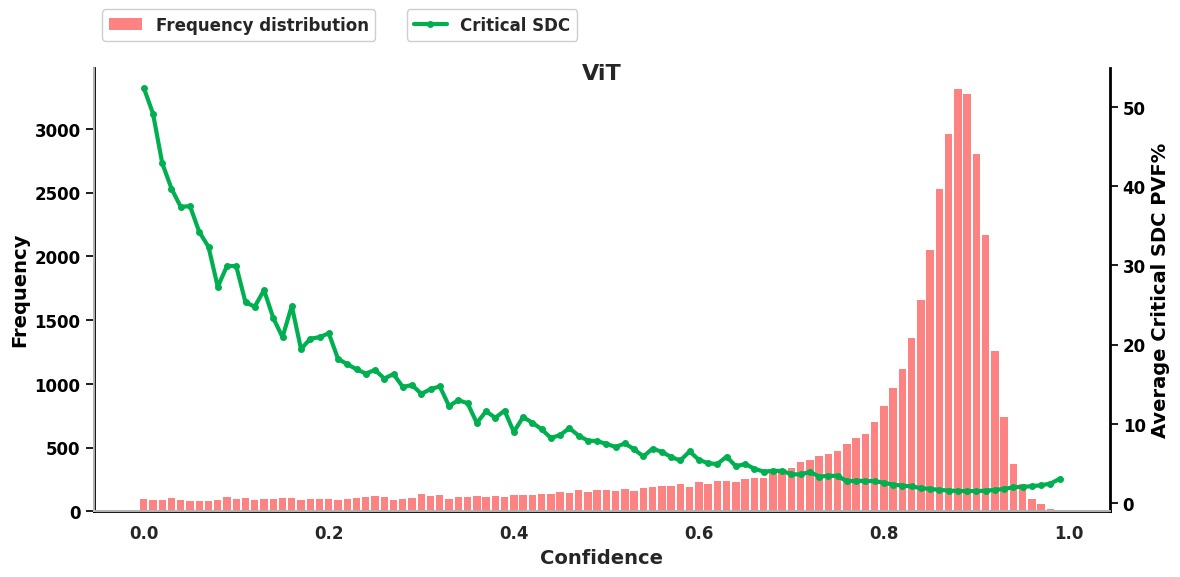

In [18]:
vit_fig = plot_binned_data(binned_vit, max_conf=1.0, min_conf=0.0, n_bins=100, model="ViT", show=True)
vit_fig.savefig(os.path.join(SAVE_PATH, "ViT_Blocks_grouped_pvf_hist.pdf"), dpi=300)

# Swin

In [19]:
swin_middle = get_concat_df_confidence("swin", "MIDDLE", overall_files)
swin_last = get_concat_df_confidence("swin", "LAST", overall_files)
swin_first = get_concat_df_confidence("swin", "FIRST", overall_files)
swin_res = [swin_last, swin_first, swin_middle]

In [20]:
test_swin_first = swin_first.copy()
test_swin_last = swin_last.copy()
test_swin_middle = swin_middle.copy()

test_swin_first["layer"] = "FIRST"
test_swin_last["layer"] = "LAST"
test_swin_middle["layer"] = "MIDDLE"

swin_grouped_test = pd.concat([test_swin_first, test_swin_last, test_swin_middle], ignore_index=True)
swin_grouped_test = swin_grouped_test.groupby(["model", "layer"]).agg({
    'SDC': lambda x: x.sum()/len(swin_grouped_test),
    'Crit SDC': lambda x: x.sum()/len(swin_grouped_test)
}).reset_index()
swin_grouped_test
# print(f"mi")

,model,layer,SDC,Crit SDC
0,swin,FIRST,19.639108,1.500015
1,swin,LAST,32.771171,0.277977
2,swin,MIDDLE,24.531461,0.988294


In [21]:
swin_grouped = pd.concat(swin_res, ignore_index=True)
swin_grouped = swin_grouped.groupby(["model", "index", "ground_truth", "prediction_without_fault"]).agg({
    'confidence': 'min',
    'SDC': lambda x: x.sum()/len(swin_res),
    'Crit SDC': lambda x: x.sum()/len(swin_res)
}).reset_index()
print(f"Min SDC% {swin_grouped['SDC'].min():.2f}")
print(f"Min Critical SDC% {swin_grouped['Crit SDC'].min():.2f}")
print(f"Max SDC% {swin_grouped['SDC'].max():.2f}")
print(f"Max Critical SDC% {swin_grouped['Crit SDC'].max():.2f}")
print(f"Average SDC% {swin_grouped['SDC'].mean():.2f}")
print(f"Average Critical SDC% {swin_grouped['Crit SDC'].mean():.2f}")

Min SDC% 0.00
Min Critical SDC% 0.00
Max SDC% 100.00
Max Critical SDC% 84.00
Average SDC% 75.20
Average Critical SDC% 2.70


In [31]:
n_bins = 100
swin_res_files = swin_block_first + swin_block_mid_last
swin_res_files = [
    os.path.join(folder, file)
    for folder in swin_res_files
    for file in os.listdir(folder)
    if file.endswith('.csv')
]

# Charger l'histogramme de référence
histogram_swin = pd.read_csv("../data/swin_base_patch4_window7_224_imagenet_fp32_top5prob_FULL.csv")
histogram_swin = histogram_swin[histogram_swin["ground_truth"] == histogram_swin["pred"]]

# Compute histogram for confidence
counts, bins = np.histogram(histogram_swin['top_diff'], bins=n_bins)
bin_midpoints = np.arange(0.0, 1.0, 0.01)

# Initialize accumulators
sdc_sum = np.zeros(n_bins)
critical_sdc_sum = np.zeros(n_bins)
bin_sample_count = np.zeros(n_bins)

# Process each fault file
for file_idx, file in enumerate(swin_res_files):
    df = pd.read_csv(file)
    
    # Calculate fault metrics
    df['SDC'] = (df['top1_w_fault'].isna()) | \
                (np.abs(df['top1_wo_fault'] - df['top1_w_fault']) > 1e-5) | \
                (df['prediction_without_fault'] != df['prediction_with_fault'])
    
    df['Crit SDC'] = df['prediction_without_fault'] != df['prediction_with_fault']
    df['confidence'] = df['top1_wo_fault'] - df['top2_wo_fault']
    
    bin_indices_current = np.digitize(df['confidence'], bins) - 1
    bin_indices_current = np.clip(bin_indices_current, 0, n_bins - 1)

    for bin_idx in range(n_bins):
        mask = bin_indices_current == bin_idx
        
        if np.any(mask):
            sdc_count_in_bin = df.loc[mask, 'SDC'].sum()
            critical_sdc_count_in_bin = df.loc[mask, 'Crit SDC'].sum()
            
            sdc_sum[bin_idx] += sdc_count_in_bin
            critical_sdc_sum[bin_idx] += critical_sdc_count_in_bin
            bin_sample_count[bin_idx] += mask.sum()

binned_swin = pd.DataFrame({
    'bin_midpoints': bin_midpoints,
    'counts': counts,
    'SDC%': sdc_sum / bin_sample_count * 100,
    'Crit SDC PVF%': critical_sdc_sum / bin_sample_count * 100,
})
binned_swin.to_excel(os.path.join(SAVE_PATH, "Swin_Blocks_grouped_pvf_hist.xlsx"))


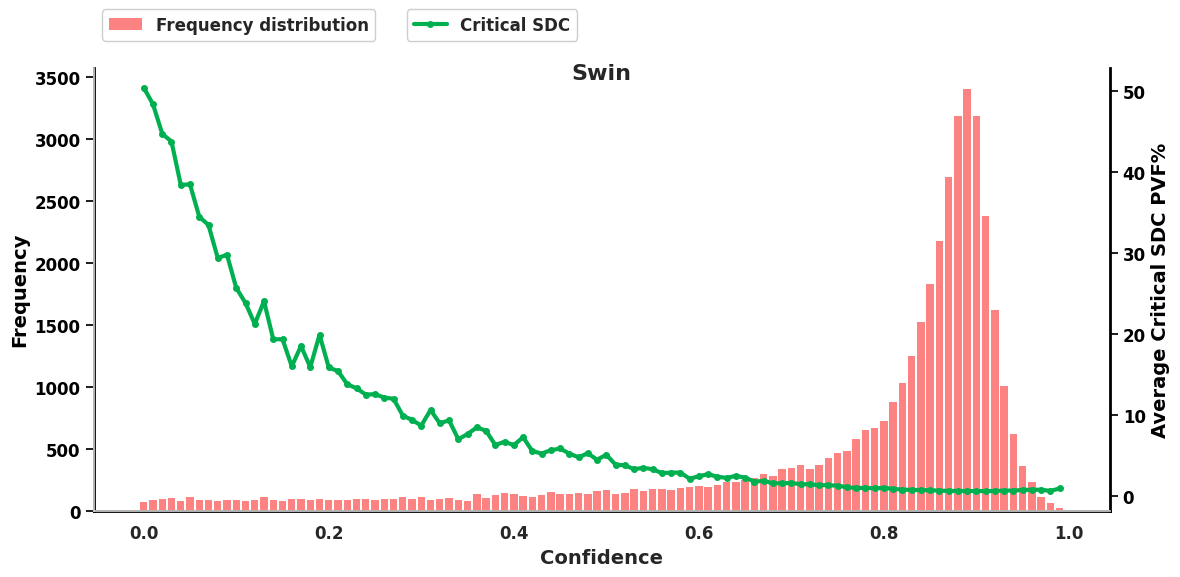

In [32]:
swin_fig = plot_binned_data(binned_swin, max_conf=1.0, min_conf=0.0, n_bins=100, model="Swin", show=True)
swin_fig.savefig(os.path.join(SAVE_PATH, "Swin_Blocks_grouped_pvf_hist.pdf"), dpi=300)

## Confidence set

Comparison of the Low-/High-confidence sets used under beam with SWFI

In [23]:
vit_low_confidence_set = get_vit_confidence_set_criticality(vit_block_first_fi + vit_block_last_fi + vit_block_mid, "low", "vit")
vit_high_confidence_set = get_vit_confidence_set_criticality(vit_block_first_fi + vit_block_last_fi + vit_block_mid, "high", "vit")

In [24]:
swin_low_confidence_set2 = get_vit_confidence_set_criticality(swin_block_first + swin_block_mid_last, "low", "swin")
swin_high_confidence_set2 = get_vit_confidence_set_criticality(swin_block_first + swin_block_mid_last, "high", "swin")

In [25]:
# df_confidence_subsets = pd.concat([vit_low_confidence_set, vit_high_confidence_set, swin_low_confidence_set, swin_high_confidence_set], ignore_index=True)
df_confidence_subsets = pd.concat([vit_low_confidence_set, vit_high_confidence_set, swin_low_confidence_set2, swin_high_confidence_set2], ignore_index=True)
df_confidence_subsets = df_confidence_subsets.groupby(["model", "subset"]).agg({
    "SDC": 'sum',
    "Crit SDC": 'sum',
}).reset_index()
df_confidence_subsets["SDC"] = df_confidence_subsets["SDC"] / 32
df_confidence_subsets["Crit SDC"] = df_confidence_subsets["Crit SDC"] / 32
df_confidence_subsets["SDC%"] = df_confidence_subsets["SDC"] / 300 * 100
df_confidence_subsets["Crit SDC%"] = df_confidence_subsets["Crit SDC"] / 300 * 100
df_confidence_subsets

,model,subset,SDC,Crit SDC,SDC%,Crit SDC%
0,swin,high,300.0,1.56250,100.0,0.520833
1,swin,low,300.0,155.25000,100.0,51.750000
2,vit,high,300.0,7.40625,100.0,2.468750
3,vit,low,300.0,152.56250,100.0,50.854167


## Comparison with random inputs from beam 

**Seed Z.** is seed = 0 and **Seed L.** is seed = 29052001

In [26]:
confidence_fi = [
    os.path.join(DATAPATH, "specific_seed"),
]

res_files_confidence_fi = [(folder, get_result_files(folder)) for folder in confidence_fi]
results_fi_confidence_fi = []

for folder, files in res_files_confidence_fi:
    results_fi_confidence_fi.extend([(parse_filename3(file), *get_criticality(os.path.join(folder, file), threshold=1e-5)) for file in files])
res_fi_confidence_fi = []
for r in results_fi_confidence_fi:
    res_fi_confidence_fi.append({
        **r[0],
        "sdc": r[2],
        "critical": r[3],
        "total images": r[4],
    })
df_fi_confidence_fi = pd.DataFrame(res_fi_confidence_fi)
df_fi_confidence_fi["SDC%"] = df_fi_confidence_fi["sdc"] / df_fi_confidence_fi["total images"] * 100
df_fi_confidence_fi["Critical SDC%"] = df_fi_confidence_fi["critical"] / df_fi_confidence_fi["total images"] * 100

In [27]:
df_fi_confidence_fi_grouped = df_fi_confidence_fi.groupby(["model", "microop", "specific_seed"]).agg({
    "sdc": "sum",
    "critical": "sum",
    "total images": "sum",
}).reset_index()

df_fi_confidence_fi_grouped["SDC%"] = df_fi_confidence_fi_grouped["sdc"] / df_fi_confidence_fi_grouped["total images"] * 100
df_fi_confidence_fi_grouped["Critical SDC%"] = df_fi_confidence_fi_grouped["critical"] / df_fi_confidence_fi_grouped["total images"] * 100
df_fi_confidence_fi_grouped = df_fi_confidence_fi_grouped[["model", "specific_seed", "SDC%", "Critical SDC%"]]
df_fi_confidence_fi_grouped.to_excel(os.path.join(SAVE_PATH, "seed_secif_fi_grouped.xlsx"), index=False)
df_fi_confidence_fi_grouped

,model,specific_seed,SDC%,Critical SDC%
0,swin_base_patch4_window7_224,0,80.552083,7.041667
1,swin_base_patch4_window7_224,29052001,77.406250,5.447917
2,vit_base_patch16_224,0,75.791667,8.052083
3,vit_base_patch16_224,29052001,66.052083,6.427083
